# German Grid Optimization: Transmission-Constrained Power Flow

**Scenario:** Optimize the dispatch of generators across Germany's
transmission network for a representative day, respecting N-1 security constraints.

**Key Questions for Utility Executives:**
- How do power flows look across a real transmission network?
- Where are the congestion bottlenecks?
- How does generation mix vary by region?

---

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pypsa

plt.style.use("bmh")
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["figure.dpi"] = 120

pypsa.options.params.optimize.log_to_console = False
print("PyPSA ready for grid optimization")

The correct version of PyPSA could not be resolved. This is likely due to a local clone without pulling tags. Please run `git fetch --tags`.


PyPSA ready for grid optimization


## 1. Load the German Transmission Network (SciGRID)

The SciGRID dataset is a model of the German high-voltage transmission grid derived from
OpenStreetMap data. It includes buses (substations), transmission lines (220kV and 380kV),
generators (coal, gas, wind, solar, nuclear, hydro), and distributed loads.

In [2]:
n = pypsa.examples.scigrid_de()
print(n)
print(f"\nBuses: {len(n.buses)}")
print(f"Lines: {len(n.lines)}")
print(f"Generators: {len(n.generators)}")
print(f"Loads: {len(n.loads)}")
print(f"Snapshots: {len(n.snapshots)}")
print(f"\nTotal generation capacity: {n.generators.p_nom.sum()/1e3:.1f} GW")
print(f"Total load: {n.loads_t.p_set.sum(axis=1).mean()/1e3:.1f} GW (average)")

INFO:pypsa.network.io:Retrieving network data from https://github.com/PyPSA/PyPSA/raw/master/examples/networks/scigrid-de/scigrid-de.nc.


INFO:pypsa.network.io:Imported network 'SciGrid-DE' has buses, carriers, generators, lines, loads, storage_units, transformers


PyPSA Network 'SciGrid-DE'

Buses: 585
Lines: 852
Generators: 1423
Loads: 489
Snapshots: 24

Total generation capacity: 172.5 GW
Total load: 50.4 GW (average)


## 2. Generation Mix by Technology

What is the installed capacity by fuel type across the German grid?

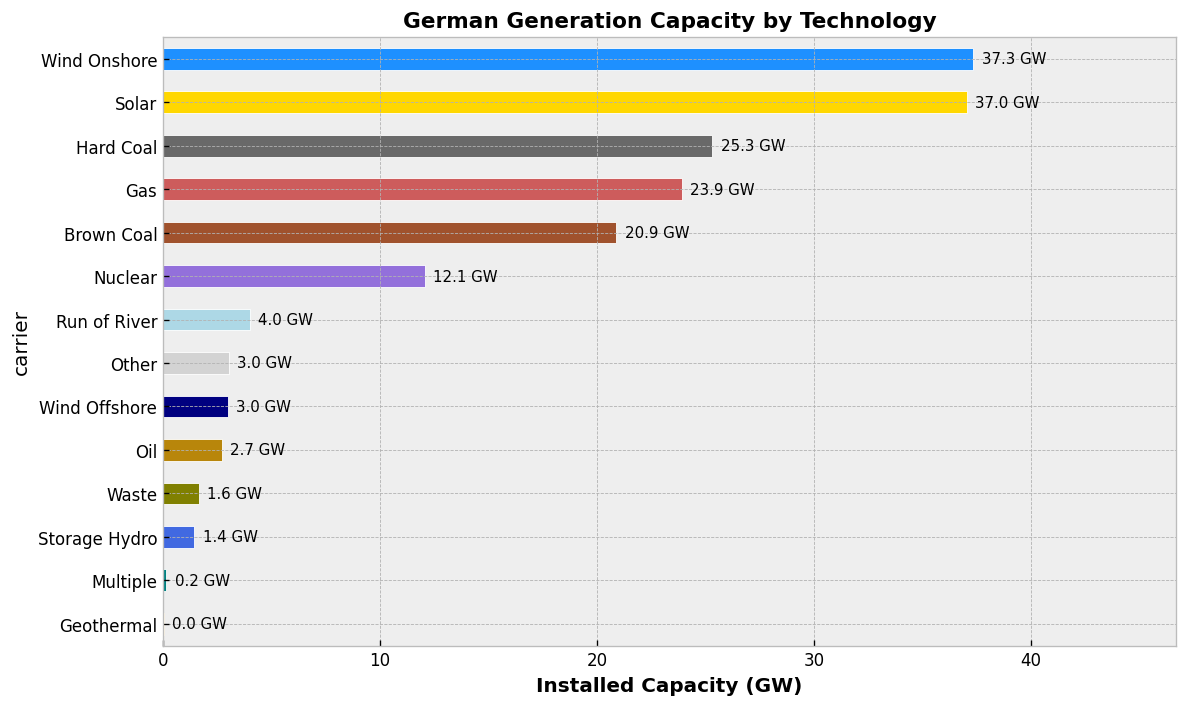


Storage capacity:
carrier
Pumped Hydro    9.1795


In [3]:
# Installed capacity by carrier
gen_cap = n.generators.groupby("carrier")["p_nom"].sum().sort_values(ascending=True) / 1e3

# Color mapping for German grid carriers
tech_colors = {
    "Wind Onshore": "dodgerblue",
    "Wind Offshore": "navy",
    "Solar": "gold",
    "Gas": "indianred",
    "Brown Coal": "sienna",
    "Hard Coal": "dimgrey",
    "Nuclear": "mediumpurple",
    "Oil": "darkgoldenrod",
    "Geothermal": "orange",
    "Waste": "olive",
    "Other": "lightgrey",
    "Biomass": "forestgreen",
    "Multiple": "teal",
    "Storage Hydro": "royalblue",
    "Run of River": "lightblue",
}

fig, ax = plt.subplots(figsize=(10, 6))
colors = [tech_colors.get(c, "grey") for c in gen_cap.index]
gen_cap.plot.barh(ax=ax, color=colors, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Installed Capacity (GW)", fontweight="bold")
ax.set_title("German Generation Capacity by Technology", fontsize=13, fontweight="bold")
ax.bar_label(ax.containers[0], fmt="%.1f GW", padding=5, fontsize=9)
ax.set_xlim(0, gen_cap.max() * 1.25)
plt.tight_layout()
plt.show()

# Storage units
if len(n.storage_units) > 0:
    su_cap = n.storage_units.groupby("carrier")["p_nom"].sum() / 1e3
    print("\nStorage capacity:")
    print(su_cap.to_string())

## 3. Geographic Network Visualization

Visualize the network topology and the distribution of load and generation across Germany.

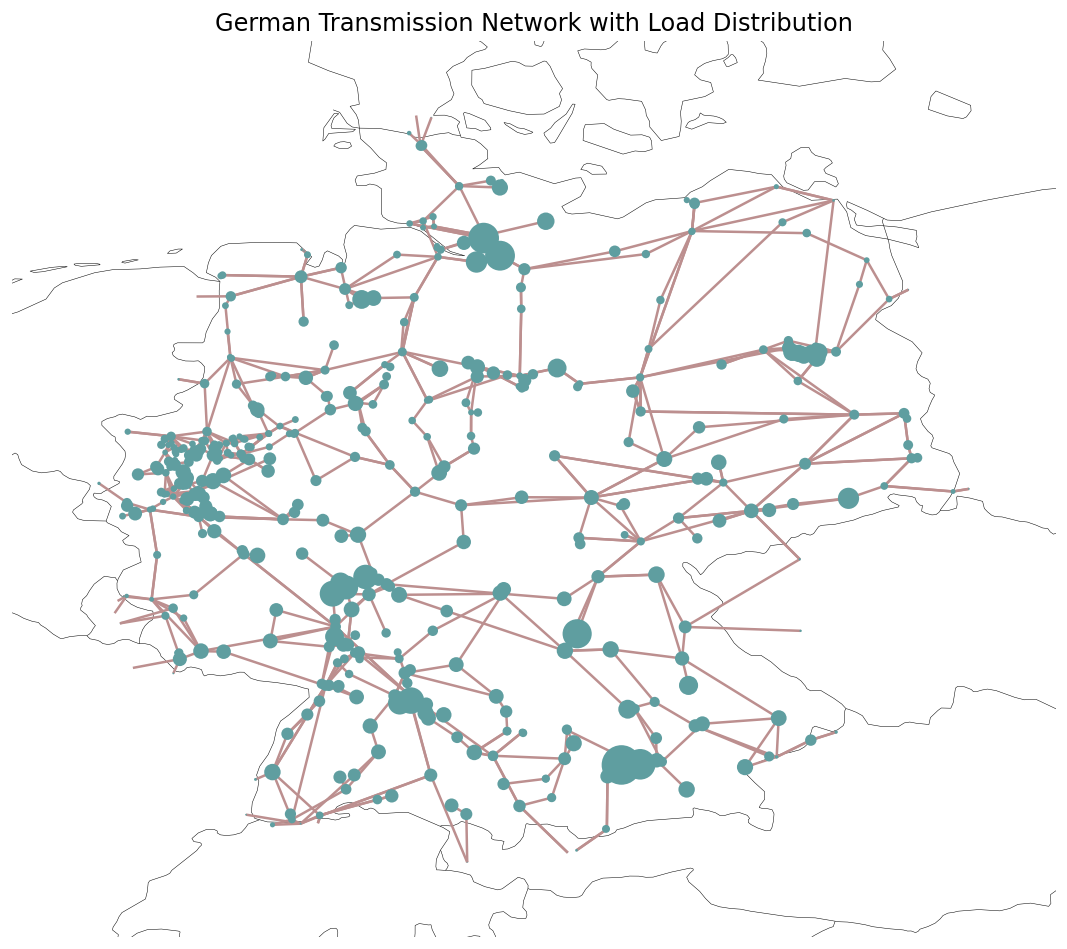

In [4]:
import cartopy.crs as ccrs

# Plot network topology with load distribution
fig, ax = plt.subplots(figsize=(9, 11),
                       subplot_kw={"projection": ccrs.PlateCarree()})

load_distribution = n.loads_t.p_set.loc[n.snapshots[0]].groupby(n.loads.bus).sum()
load_distribution = load_distribution.reindex(n.buses.index, fill_value=0)

n.plot(
    bus_size=load_distribution / 30000,
    ax=ax,
    title="German Transmission Network with Load Distribution",
    margin=0.1,
)
plt.tight_layout()
plt.show()

Available carriers: ['Brown Coal', 'Gas', 'Geothermal', 'Hard Coal', 'Multiple', 'Nuclear', 'Oil', 'Other', 'Run of River', 'Solar', 'Storage Hydro', 'Waste', 'Wind Offshore', 'Wind Onshore']

Plotting top 6 carriers: ['Wind Onshore', 'Solar', 'Hard Coal', 'Gas', 'Brown Coal', 'Nuclear']


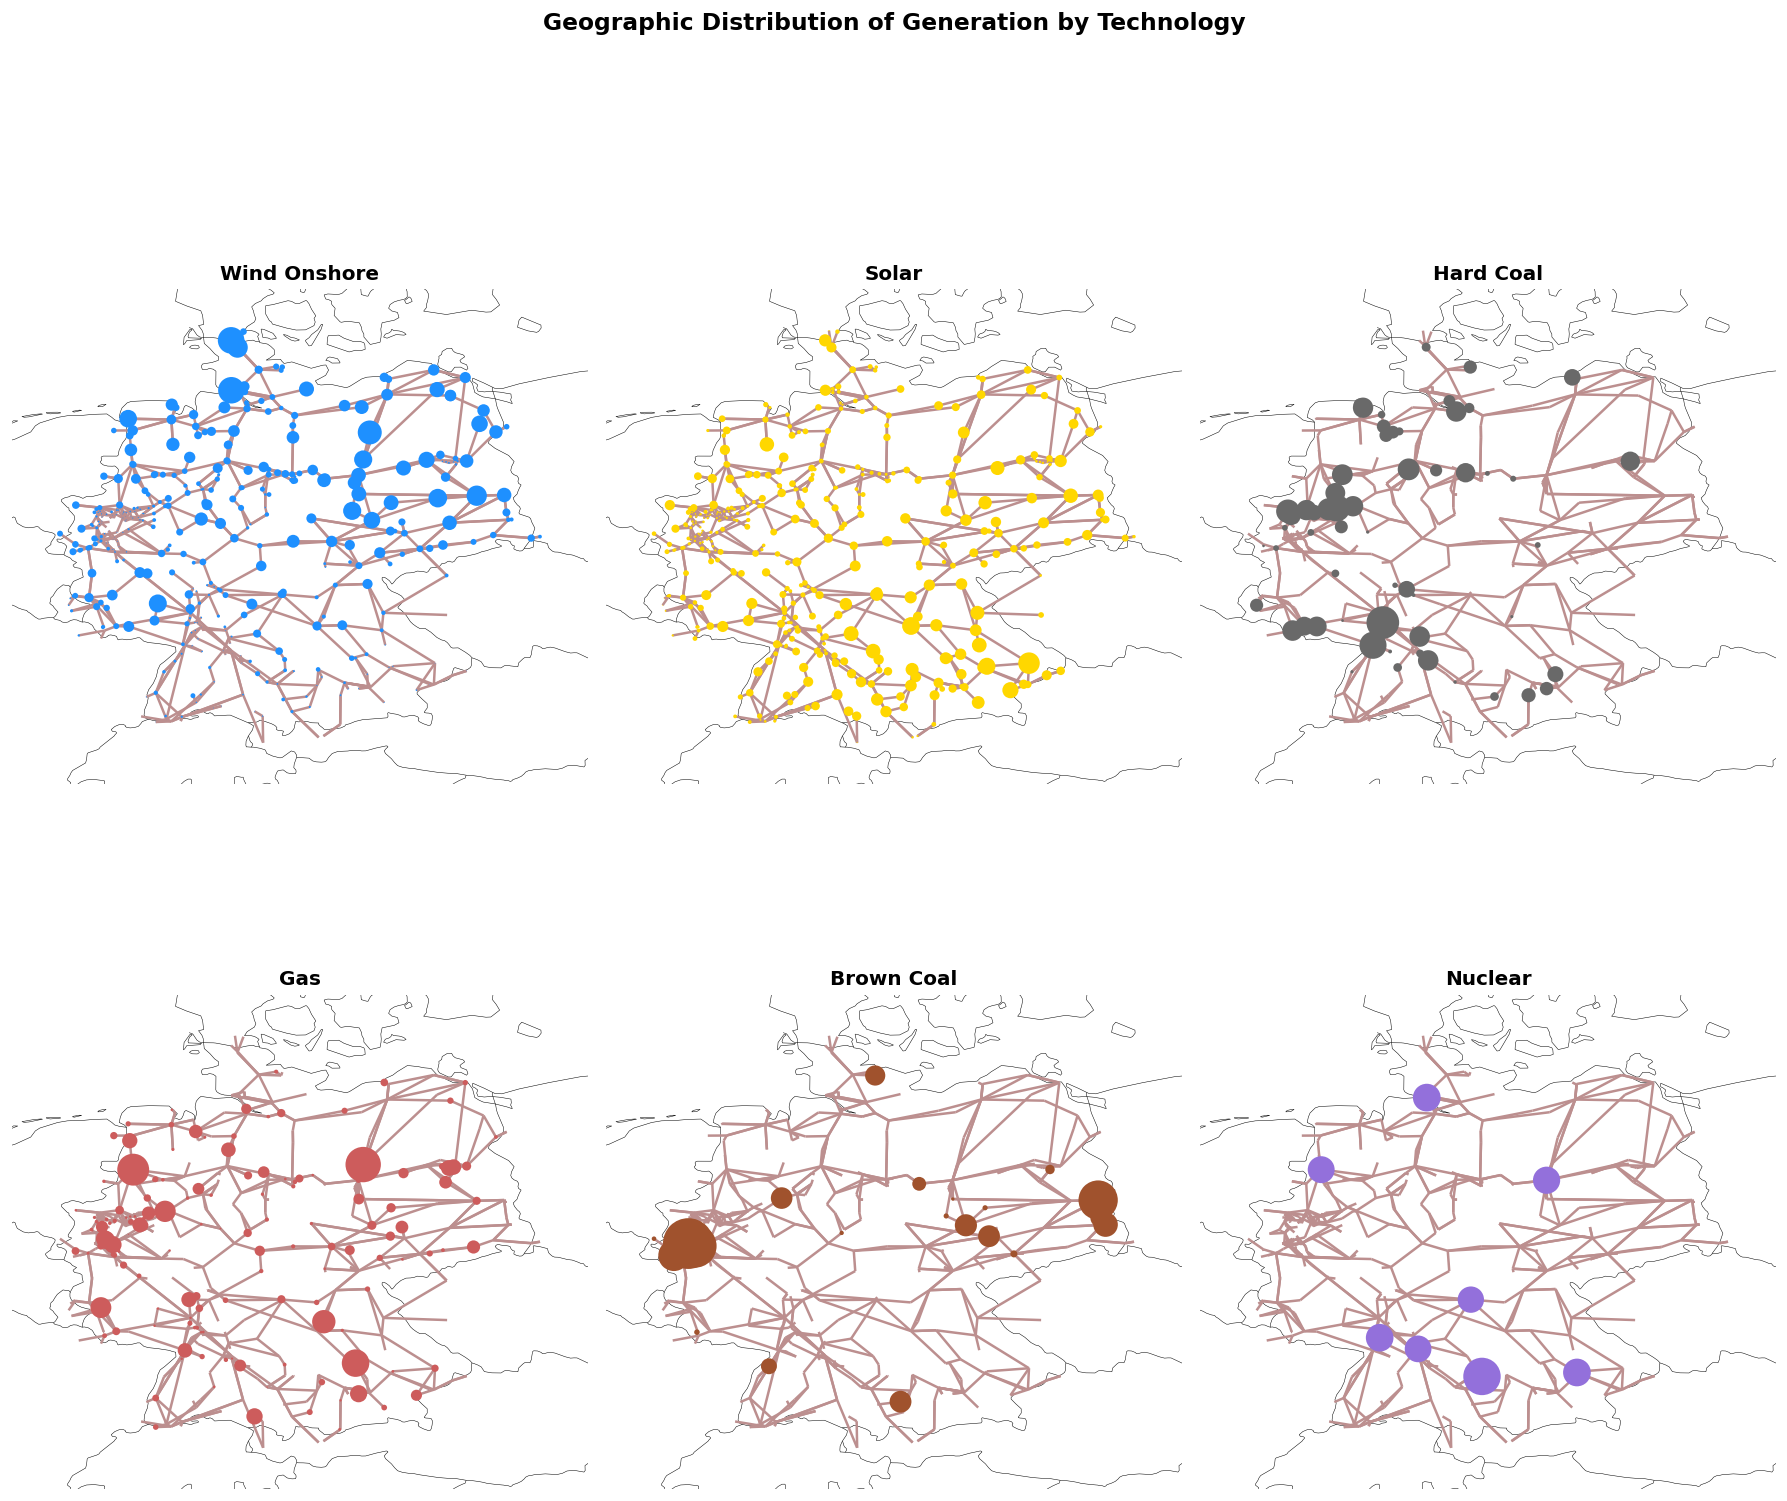

In [5]:
# Plot generation distribution for selected technologies
available_carriers = n.generators.carrier.unique()
print(f"Available carriers: {sorted(available_carriers)}")

# Select top carriers by capacity
top_carriers = n.generators.groupby("carrier")["p_nom"].sum().nlargest(6).index.tolist()
print(f"\nPlotting top 6 carriers: {top_carriers}")

n_cols = 3
n_rows = 2
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(5 * n_cols, 7 * n_rows),
                         subplot_kw={"projection": ccrs.PlateCarree()})

for i, tech in enumerate(top_carriers):
    i_row = i // n_cols
    i_col = i % n_cols
    ax = axes[i_row, i_col]

    gens = n.generators[n.generators.carrier == tech]
    gen_distribution = (
        gens.groupby("bus").sum(numeric_only=True)["p_nom"]
        .reindex(n.buses.index, fill_value=0)
    )
    color = tech_colors.get(tech, "grey")
    n.plot(ax=ax, bus_size=gen_distribution / 20000, bus_colors=color, margin=0.1)
    ax.set_title(tech, fontweight="bold", fontsize=12)

fig.suptitle("Geographic Distribution of Generation by Technology",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

## 4. Run Linear Optimal Power Flow (LOPF)

We optimize the dispatch of all generators while respecting:
- **Network constraints** (Kirchhoff's voltage law, thermal limits)
- **N-1 security** via a 70% thermal rating limit on all lines
- **Generator limits** (min/max output, ramp rates)

This is the core computation that utilities need for day-ahead market clearing
and congestion management.

In [6]:
# Apply N-1 contingency factor (reduce line ratings to 70%)
contingency_factor = 0.7
n.lines.s_max_pu = contingency_factor

# Ensure there is enough generation slack
# Scale up marginal generators to make the problem feasible under N-1
for gen in n.generators.index:
    if n.generators.at[gen, "p_nom"] > 0 and not n.generators.at[gen, "p_nom_extendable"]:
        n.generators.at[gen, "p_nom"] *= 1.2

# Run the linear optimal power flow
status, termination_condition = n.optimize()
print(f"Optimization status: {status}")
if n.objective is not None:
    print(f"Total system cost: EUR {n.objective:,.0f}")
else:
    print("Optimization did not converge - running without N-1 constraint")
    n.lines.s_max_pu = 1.0
    contingency_factor = 1.0
    status, termination_condition = n.optimize()
    print(f"Re-run status: {status}")
    print(f"Total system cost: EUR {n.objective:,.0f}")

# Generation by carrier
gen_by_carrier = {}
for carrier in n.generators.carrier.unique():
    mask = n.generators.carrier == carrier
    gen_by_carrier[carrier] = n.generators_t.p.loc[:, mask].sum().sum() / 1e3
gen_by_carrier = pd.Series(gen_by_carrier)
print(f"\nGeneration by carrier (GWh):")
print(gen_by_carrier.sort_values(ascending=False).to_string(float_format="{:.1f}".format))

Index(['2', '5', '10', '12', '13', '15', '18', '20', '22', '24', '26', '30',
       '32', '37', '42', '46', '52', '56', '61', '68', '69', '74', '78', '86',
       '87', '94', '95', '96', '99', '100', '104', '105', '106', '107', '117',
       '120', '123', '124', '125', '128', '129', '138', '143', '156', '157',
       '159', '160', '165', '184', '191', '195', '201', '220', '231', '232',
       '233', '236', '247', '248', '250', '251', '252', '261', '263', '264',
       '267', '272', '279', '281', '282', '292', '303', '307', '308', '312',
       '315', '317', '322', '332', '334', '336', '338', '351', '353', '360',
       '362', '382', '384', '385', '391', '403', '404', '413', '421', '450',
       '458'],
      dtype='object', name='name')


INFO:linopy.model: Solve problem using Highs solver


INFO:linopy.model:Solver options:
 - log_to_console: False


INFO:linopy.io:Writing objective.


Writing constraints.:   0%|                              | 0/15 [00:00<?, ?it/s]

...

Writing continuous variables.: 100%|█████████████| 6/6 [00:00<00:00, 260.38it/s]


INFO:linopy.io: Writing time: 0.23s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 59640 primals, 142968 duals
Objective: 5.18e+06
Solver model: available
Solver message: Optimal



INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, Transformer-fix-s-lower, Transformer-fix-s-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


Re-run status: ok
Total system cost: EUR 5,182,135

Generation by carrier (GWh):
Wind Onshore    488.4
Brown Coal      239.7
Nuclear         202.2
Run of River     99.7
Solar            54.4
Wind Offshore    48.0
Waste            38.3
Storage Hydro    29.7
Hard Coal        16.6
Gas               0.7
Other             0.2
Geothermal        0.0
Oil               0.0
Multiple          0.0


## 5. Visualize Power Flows on the Network

Map the optimized power flows onto the geographic network.
Line widths represent power flow magnitude; colors indicate loading level.

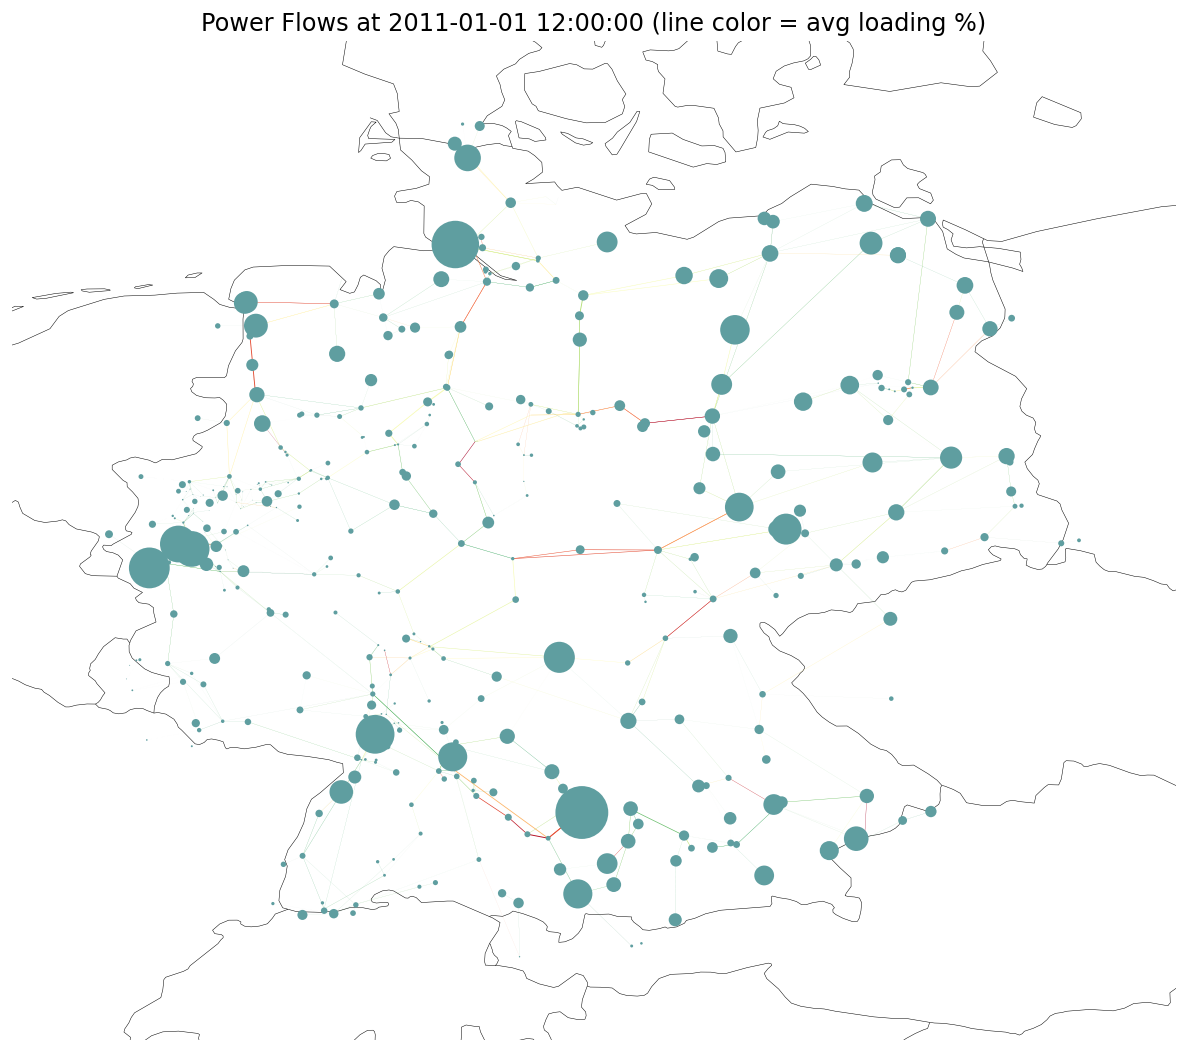

In [7]:
# Calculate line loading
line_loading = n.lines_t.p0.abs().mean() / (n.lines.s_nom * contingency_factor) * 100

# Plot network with power flows for midday
hour = n.snapshots[min(12, len(n.snapshots) - 1)]

fig, ax = plt.subplots(1, 1, figsize=(10, 12),
                       subplot_kw={"projection": ccrs.PlateCarree()})

# Bus sizes by net generation
bus_generation = n.generators_t.p.loc[hour].groupby(n.generators.bus).sum()
bus_generation = bus_generation.reindex(n.buses.index, fill_value=0)

n.plot(
    ax=ax,
    bus_size=bus_generation / 50000,
    line_widths=n.lines_t.p0.loc[hour].abs() / 3000,
    line_colors=line_loading,
    line_cmap=plt.cm.RdYlGn_r,
    title=f"Power Flows at {hour} (line color = avg loading %)",
    margin=0.1,
)

plt.tight_layout()
plt.show()

## 6. Line Loading Analysis: Where Is Congestion?

Identifying the most congested lines is critical for grid planning and investment decisions.

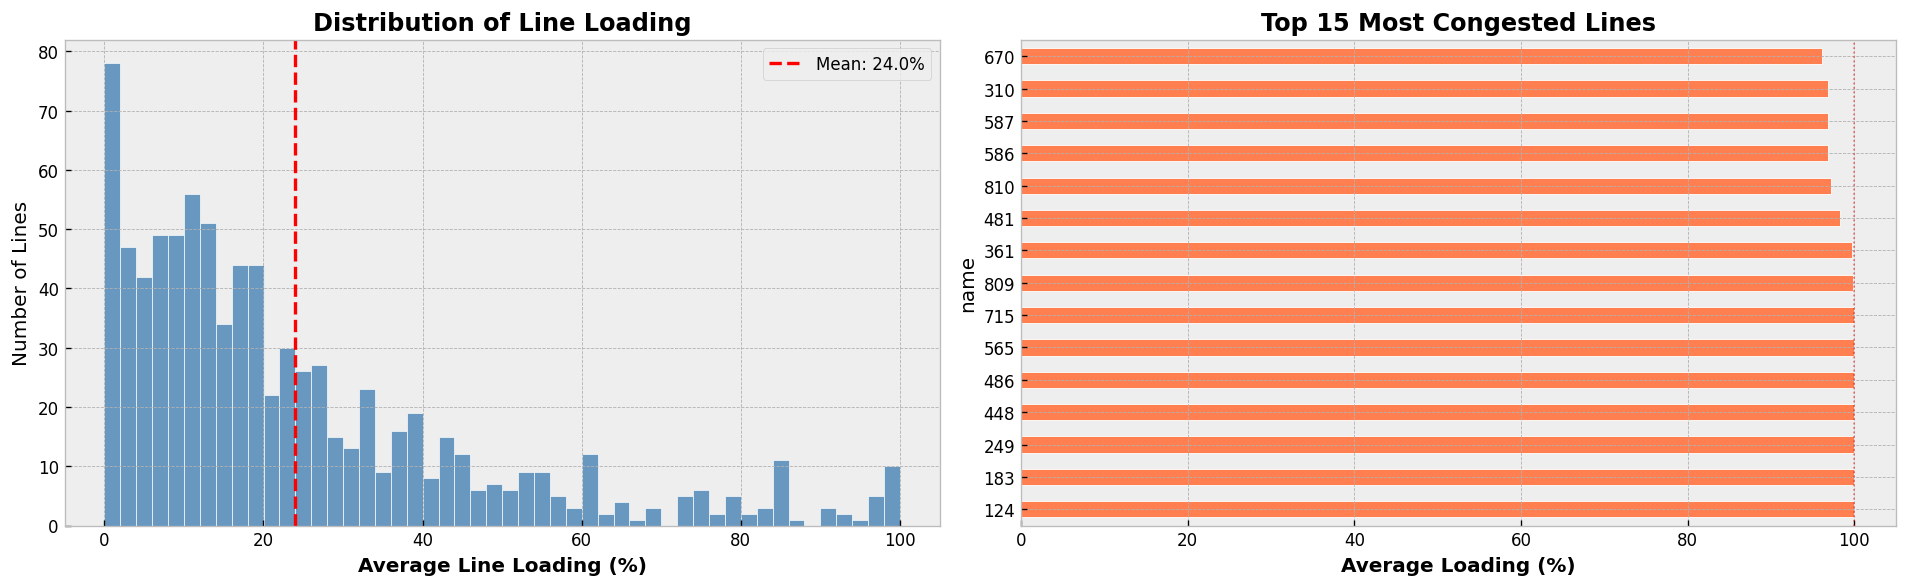

Lines above 80% average loading: 38
Lines above 90% average loading: 21
Lines above 100% average loading: 0


In [8]:
# Average and max line loading
loading_stats = pd.DataFrame({
    "Avg Loading (%)": line_loading,
    "Max Loading (%)": n.lines_t.p0.abs().max() / (n.lines.s_nom * contingency_factor) * 100,
    "Capacity (MW)": n.lines.s_nom * contingency_factor,
})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of line loading
axes[0].hist(line_loading, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(line_loading.mean(), color="red", linestyle="--",
                label=f"Mean: {line_loading.mean():.1f}%")
axes[0].set_xlabel("Average Line Loading (%)", fontweight="bold")
axes[0].set_ylabel("Number of Lines")
axes[0].set_title("Distribution of Line Loading", fontweight="bold")
axes[0].legend()

# Top 15 most loaded lines
top_loaded = loading_stats.nlargest(15, "Avg Loading (%)")
top_loaded["Avg Loading (%)"].plot.barh(ax=axes[1], color="coral", edgecolor="white")
axes[1].set_xlabel("Average Loading (%)", fontweight="bold")
axes[1].set_title("Top 15 Most Congested Lines", fontweight="bold")
axes[1].axvline(100, color="red", linestyle=":", linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Lines above 80% average loading: {(line_loading > 80).sum()}")
print(f"Lines above 90% average loading: {(line_loading > 90).sum()}")
print(f"Lines above 100% average loading: {(line_loading > 100).sum()}")

## 7. Generation Dispatch Over the Day

How does the generation mix evolve hour-by-hour across the network?

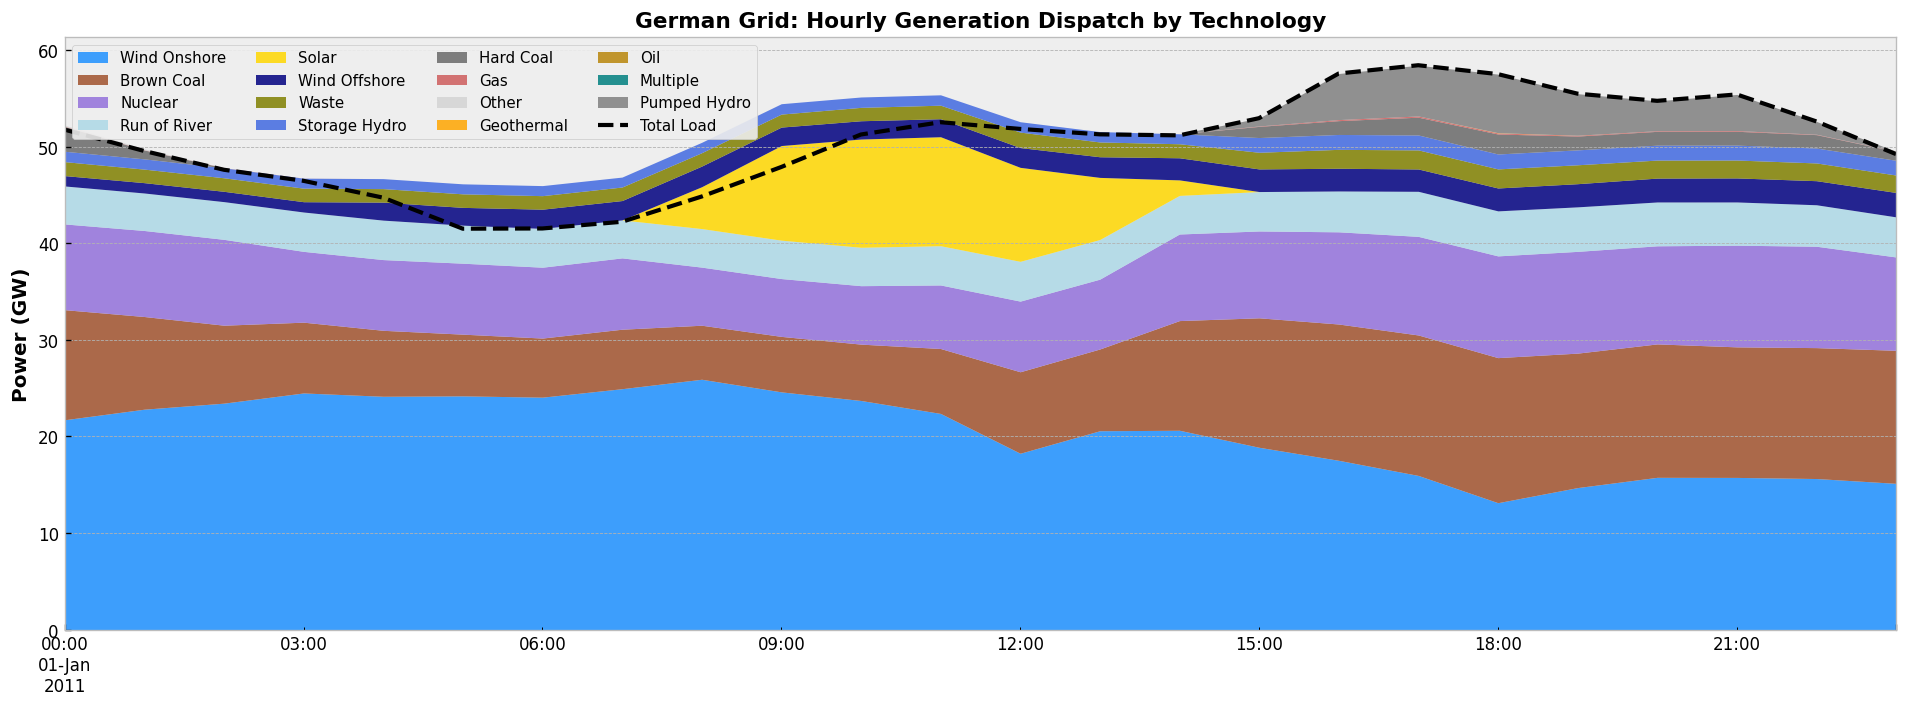

In [9]:
# Aggregate generation by carrier over time
gen_dispatch = {}
for carrier in n.generators.carrier.unique():
    mask = n.generators.carrier == carrier
    gen_dispatch[carrier] = n.generators_t.p.loc[:, mask].sum(axis=1) / 1e3
gen_dispatch = pd.DataFrame(gen_dispatch)

# Add storage dispatch if present
if len(n.storage_units) > 0:
    for carrier in n.storage_units.carrier.unique():
        mask = n.storage_units.carrier == carrier
        gen_dispatch[carrier] = n.storage_units_t.p.loc[:, mask].sum(axis=1) / 1e3

# Sort by total generation
order = gen_dispatch.sum().sort_values(ascending=False).index
gen_dispatch = gen_dispatch[order]

# Get colors
dispatch_colors = [tech_colors.get(c, "grey") for c in gen_dispatch.columns]

fig, ax = plt.subplots(figsize=(16, 6))
gen_dispatch.clip(lower=0).plot.area(ax=ax, color=dispatch_colors, linewidth=0, alpha=0.85)

# Overlay total load
total_load = n.loads_t.p.sum(axis=1) / 1e3
total_load.plot(ax=ax, color="black", linewidth=2.5, linestyle="--", label="Total Load")

ax.set_ylabel("Power (GW)", fontweight="bold")
ax.set_xlabel("")
ax.set_title("German Grid: Hourly Generation Dispatch by Technology", fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=9, ncol=4, framealpha=0.9)
plt.tight_layout()
plt.show()

## 8. Locational Marginal Prices

The nodal prices (shadow prices) reveal where electricity is most valuable
and where congestion creates price differences.

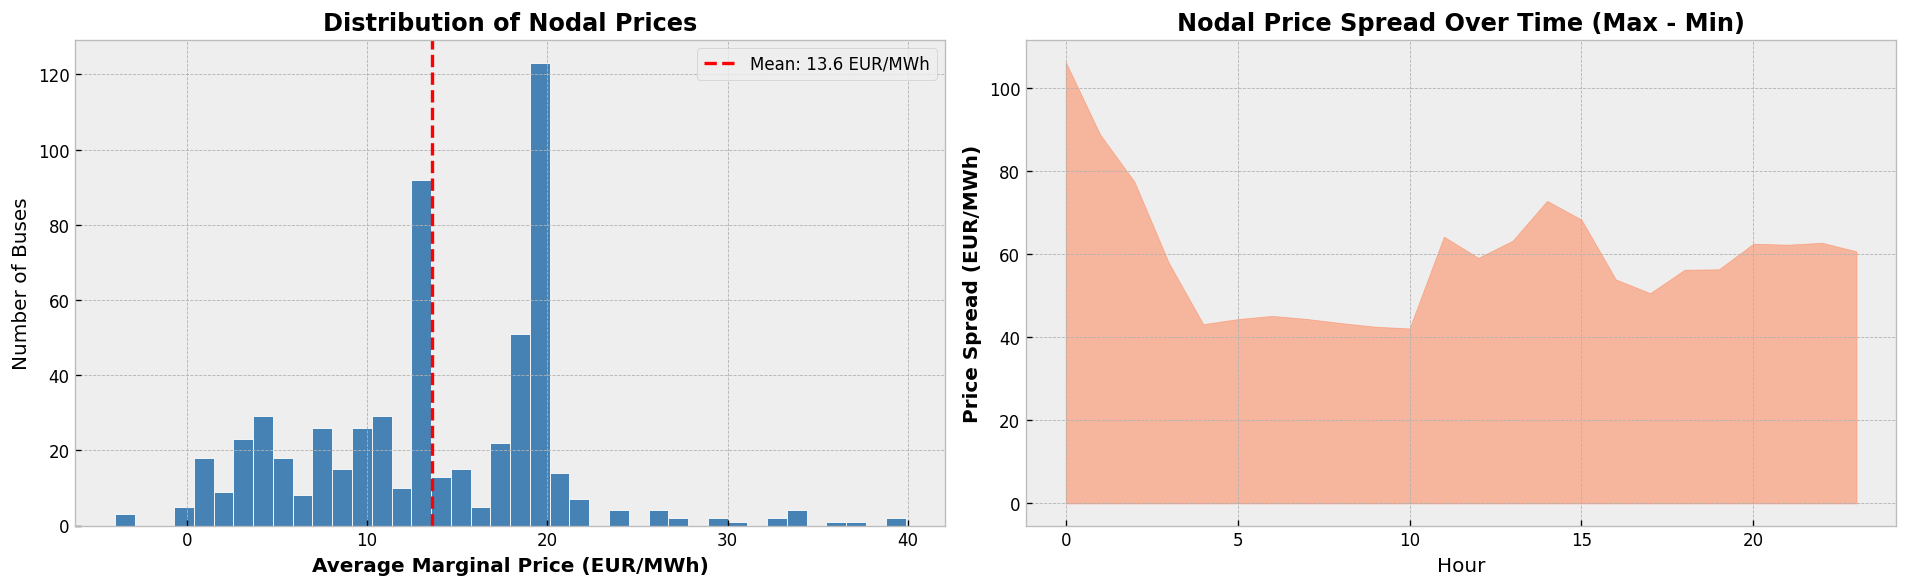

Average system price: EUR 13.61/MWh
Max nodal price spread: EUR 106.15/MWh


In [10]:
# Calculate average nodal prices
avg_prices = n.buses_t.marginal_price.mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Price distribution
nonzero_prices = avg_prices[avg_prices != 0]
if len(nonzero_prices) > 0:
    axes[0].hist(nonzero_prices, bins=40, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("Average Marginal Price (EUR/MWh)", fontweight="bold")
    axes[0].set_ylabel("Number of Buses")
    axes[0].set_title("Distribution of Nodal Prices", fontweight="bold")
    axes[0].axvline(nonzero_prices.mean(), color="red", linestyle="--",
                    label=f"Mean: {nonzero_prices.mean():.1f} EUR/MWh")
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, "No price data available", ha="center", va="center",
                 transform=axes[0].transAxes)

# Price time series spread
price_spread = n.buses_t.marginal_price.max(axis=1) - n.buses_t.marginal_price.min(axis=1)
axes[1].fill_between(range(len(price_spread)), price_spread.values, alpha=0.5, color="coral")
axes[1].set_ylabel("Price Spread (EUR/MWh)", fontweight="bold")
axes[1].set_title("Nodal Price Spread Over Time (Max - Min)", fontweight="bold")
axes[1].set_xlabel("Hour")

plt.tight_layout()
plt.show()

if len(nonzero_prices) > 0:
    print(f"Average system price: EUR {nonzero_prices.mean():.2f}/MWh")
    print(f"Max nodal price spread: EUR {price_spread.max():.2f}/MWh")

## 9. Network Statistics Summary

PyPSA provides built-in statistics for quick analysis of results.

In [11]:
# Summary statistics
print("=== Network Summary ===")
print(f"Total generation: {n.generators_t.p.sum().sum()/1e3:.1f} GWh")
print(f"Total load served: {n.loads_t.p.sum().sum()/1e3:.1f} GWh")
print(f"System cost: EUR {n.objective:,.0f}")

# Curtailment check
if hasattr(n.generators_t, "p") and hasattr(n.generators, "p_max_pu"):
    available = (n.generators_t.p_max_pu * n.generators.p_nom).sum().sum()
    actual = n.generators_t.p.sum().sum()
    if available > actual:
        print(f"\nCurtailment: {(available - actual)/1e3:.1f} GWh ({(1 - actual/available)*100:.1f}%)")
    else:
        print("\nNo curtailment observed")

# Line utilization summary
print(f"\n=== Line Utilization ===")
print(f"Average line loading: {line_loading.mean():.1f}%")
print(f"Median line loading: {line_loading.median():.1f}%")
print(f"Max line loading: {line_loading.max():.1f}%")
print(f"Lines above 80%: {(line_loading > 80).sum()} / {len(line_loading)}")

=== Network Summary ===
Total generation: 1217.8 GWh
Total load served: 1210.0 GWh
System cost: EUR 5,182,135

No curtailment observed

=== Line Utilization ===
Average line loading: 24.0%
Median line loading: 16.8%
Max line loading: 100.0%
Lines above 80%: 38 / 852


## 10. Executive Summary

### Key Takeaways
1. **Network congestion is real** — even with N-1 security margins, several lines operate near thermal limits
2. **Regional generation imbalances** — wind is concentrated in the north, coal in the west, solar in the south
3. **Nodal price differences** reveal congestion rents and the value of transmission upgrades
4. **Dispatchable generation** (coal, gas) runs at the margin, setting system-wide prices
5. **Grid topology matters** — optimal dispatch changes significantly when network constraints are enforced

### What This Means for Utility Planning
- Transmission planning must account for the geographic mismatch between renewable generation and load centers
- Congestion management is a growing operational challenge as renewables increase
- Locational marginal pricing reveals where grid investments have the highest return
- PyPSA can scale from this model to full European network models (10,000+ buses)

---
*Built with [PyPSA](https://pypsa.org) — Python for Power System Analysis*